# Volatility Paper Code

Import required packages

In [36]:
from __future__ import annotations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from dataclasses import dataclass
from typing import Dict, Optional, Tuple, List
import warnings
warnings.filterwarnings('ignore')

# Add Numba for performance
try:
    from numba import jit, prange
    NUMBA_AVAILABLE = True
    print("✓ Numba JIT compilation enabled")
except ImportError:
    print("⚠ Install numba for 5-10x speedup: pip install numba")
    NUMBA_AVAILABLE = False
    def jit(*args, **kwargs):
        return lambda f: f
    prange = range

✓ Numba JIT compilation enabled


Plot Figure for Paper

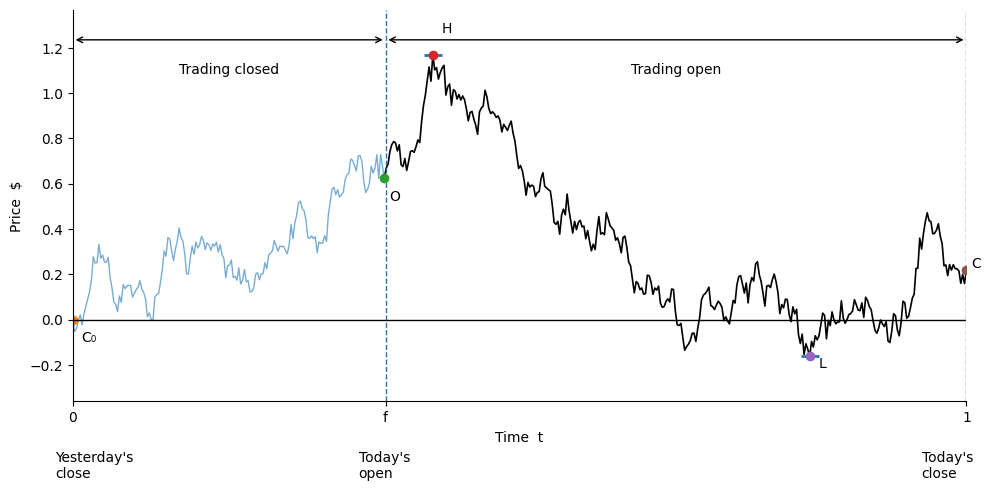

In [37]:

# parameters
seed = 100
N = 480                # points over the day
f = 0.35               # open fraction in [0,1]
rng = np.random.default_rng(seed)

# simulate a simple Brownian-like path
t = np.linspace(0, 1, N)
dt = 1 / (N - 1)
x = np.concatenate([[0.0], np.cumsum(np.sqrt(dt) * rng.standard_normal(N - 1))])

# pick open, high, low, close
i_open = int(f * (N - 1))
seg = x[i_open:]
iH = i_open + np.argmax(seg)
iL = i_open + np.argmin(seg)

C0 = x[0]
O  = x[i_open]
H  = x[iH]
L  = x[iL]
C  = x[-1]

fig, ax = plt.subplots(figsize=(10, 5))

# closed vs open periods
ax.plot(t[:i_open+1], x[:i_open+1], lw=1, alpha=0.6)
ax.plot(t[i_open:], x[i_open:], lw=1.2, color="black")

# vertical dashed lines for open and close
ax.axvline(f, ls="--", lw=1)
ax.axvline(1, ls="--", lw=1)

# small horizontal ticks at H and L
tick_w = 0.02
ax.hlines(H, t[iH]-tick_w/2, t[iH]+tick_w/2, lw=2)
ax.hlines(L, t[iL]-tick_w/2, t[iL]+tick_w/2, lw=2)

# point markers
ax.plot(t[0], C0, "o")
ax.plot(t[i_open], O, "o")
ax.plot(t[iH], H, "o")
ax.plot(t[iL], L, "o")
ax.plot(t[-1], C, "o")

# labels for points
ax.annotate("C₀", (t[0], C0), xytext=(t[0]+0.01, C0-0.1))
ax.annotate("O",  (t[i_open], O), xytext=(t[i_open]+0.005, O-0.1))
ax.annotate("H",  (t[iH], H), xytext=(t[iH]+0.01, H+0.1))
ax.annotate("L",  (t[iL], L), xytext=(t[iL]+0.01, L-0.05))
ax.annotate("C",  (t[-1], C), xytext=(t[-1]+0.005, C+0.01))

# x-axis ticks and labels
ax.set_xticks([0, f, 1])
ax.set_xticklabels(["0", "f", "1"])
ax.axhline(0, lw=1, color="black")

# bottom captions
ax.annotate("Yesterday's\nclose", (0, 0), xytext=(-0.02, -0.7))
ax.annotate("Today's\nopen", (f, 0), xytext=(f-0.03, -0.7))
ax.annotate("Today's\nclose", (1, 0), xytext=(1-0.05, -0.7))

# top timeline arrows
ax.annotate("", xy=(0, ax.get_ylim()[1]), xytext=(f, ax.get_ylim()[1]),
            arrowprops=dict(arrowstyle="<->"))
ax.annotate("", xy=(f, ax.get_ylim()[1]), xytext=(1, ax.get_ylim()[1]),
            arrowprops=dict(arrowstyle="<->"))
ax.text(0.5*f, ax.get_ylim()[1]-0.1, "Trading closed", ha="center", va="top")
ax.text((1+f)/2, ax.get_ylim()[1]-0.1, "Trading open", ha="center", va="top")

# axis labels
ax.set_ylabel("Price  $")
ax.set_xlabel("Time  t")

# cosmetics
ax.set_xlim(0, 1)
ax.margins(y=0.15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("simple_OHLC_diagram.png", dpi=300, bbox_inches="tight")
plt.show()

In [38]:
# helper functions
def _safe_log(x: np.ndarray) -> np.ndarray:
    """Numerically safe natural log."""
    return np.log(np.clip(x, 1e-300, None))

def _require_columns(df: pd.DataFrame, cols: List[str]) -> None:
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"DataFrame missing required columns: {missing}")

@dataclass
class EstimatorResults:
    """Container for per‑day estimates and an aggregate scalar."""
    per_day: pd.Series
    aggregate: float

Functions for Classical Estimators

In [39]:
def cc_variance(df: pd.DataFrame) -> EstimatorResults:
    """
    Close‑to‑close (CC): per day r_t^2 with r_t = ln(C_t/C_{t-1}).
    Aggregate = mean of daily r^2.
    """
    _require_columns(df, ["Close"])
    close = df["Close"].to_numpy(float)
    r = _safe_log(close[1:] / close[:-1])
    per_day = pd.Series(np.concatenate([[np.nan], r**2]), index=df.index, name="CC")
    return EstimatorResults(per_day=per_day, aggregate=float(np.nanmean(per_day)))

def parkinson_variance(df: pd.DataFrame) -> EstimatorResults:
    """
    Parkinson (1980): (1/(4 ln 2)) * [ln(H/L)]^2 per day; aggregate = mean.
    """
    _require_columns(df, ["High", "Low"])
    hl = _safe_log(df["High"].to_numpy(float) / df["Low"].to_numpy(float))
    per_day = pd.Series((hl**2) / (4.0 * math.log(2.0)), index=df.index, name="PK")
    return EstimatorResults(per_day=per_day, aggregate=float(np.nanmean(per_day)))

def garman_klass_variance(df: pd.DataFrame) -> EstimatorResults:
    """
    Garman–Klass practical (no drift):
      0.5 * [ln(H/L)]^2  - (2 ln 2 - 1) * [ln(C/O)]^2
    """
    _require_columns(df, ["Open", "High", "Low", "Close"])
    O, H, L, C = (df[c].to_numpy(float) for c in ["Open", "High", "Low", "Close"])
    h_l = _safe_log(H / L)
    c_o = _safe_log(C / O)
    per_day = pd.Series(0.5*h_l**2 - (2.0*math.log(2.0) - 1.0)*c_o**2,
                        index=df.index, name="GK")
    return EstimatorResults(per_day=per_day, aggregate=float(np.nanmean(per_day)))

def rogers_satchell_variance(df: pd.DataFrame) -> EstimatorResults:
    """
    Rogers–Satchell (drift‑robust) per day:
      u*(u - c) + d*(d - c) where u=ln(H/O), d=ln(L/O), c=ln(C/O).
    """
    _require_columns(df, ["Open", "High", "Low", "Close"])
    O, H, L, C = (df[c].to_numpy(float) for c in ["Open", "High", "Low", "Close"])
    u = _safe_log(H / O); d = _safe_log(L / O); c = _safe_log(C / O)
    per_day = pd.Series(u*(u - c) + d*(d - c), index=df.index, name="RS")
    return EstimatorResults(per_day=per_day, aggregate=float(np.nanmean(per_day)))

def yang_zhang_variance(df: pd.DataFrame, alpha: float = 1.34) -> EstimatorResults:
    """
    Yang–Zhang multi‑period:
      V = VO + k*VC + (1 - k)*VRS, with
      VO = sample var of o_i = ln(O_i / C_{i-1})
      VC = sample var of c_i = ln(C_i / O_i)
      VRS = mean of RS_i (per‑day RS term)
      k = (alpha - 1) / (alpha + 1 + 2/(n - 1))
    Returns per_day = RS component (for plotting) and aggregate scalar V.
    """
    _require_columns(df, ["Open", "High", "Low", "Close"])
    O, H, L, C = (df[c].to_numpy(float) for c in ["Open", "High", "Low", "Close"])
    C_prev = np.concatenate([[np.nan], C[:-1]])
    o = _safe_log(O / C_prev)  # overnight; first NaN
    c = _safe_log(C / O)
    u = _safe_log(H / O); d = _safe_log(L / O)
    rs = u*(u - c) + d*(d - c)

    mask = ~np.isnan(o); n = int(mask.sum())
    if n < 2: raise ValueError("Need ≥2 periods for YZ.")
    VO = float(np.var(o[mask], ddof=1))
    VC = float(np.var(c[mask], ddof=1))
    VRS = float(np.mean(rs[mask]))
    k = (alpha - 1.0) / (alpha + 1.0 + 2.0/(n - 1.0))
    V = VO + k*VC + (1.0 - k)*VRS

    return EstimatorResults(per_day=pd.Series(rs, index=df.index, name="YZ_component_RS"),
                            aggregate=V)


def yang_zhang_with_components(df: pd.DataFrame, alpha: float = 1.34):
    """
    Yang–Zhang (2000) with component outputs:
      VO  = sample variance of overnight returns  o_i = ln(O_i / C_{i-1})
      VC  = sample variance of intraday c_i       c_i = ln(C_i / O_i)
      RS̄  = mean of per-day Rogers–Satchell terms
      k   = (alpha - 1) / (alpha + 1 + 2/(n - 1))
      VYZ = VO + k*VC + (1 - k)*RS̄          (scalar multi-period estimate)

    Returns:
      {
        "VYZ": float,
        "VO": float,
        "VC": float,
        "RS_bar": float,
        "k": float,
        "o_series": pd.Series,   # overnight returns per day (first is NaN)
        "c_series": pd.Series,   # ln(C/O) per day
        "rs_series": pd.Series,  # RS term per day
      }
    """
    _require_columns(df, ["Open", "High", "Low", "Close"])
    O = df["Open"].to_numpy(float)
    H = df["High"].to_numpy(float)
    L = df["Low"].to_numpy(float)
    C = df["Close"].to_numpy(float)

    C_prev = np.concatenate([[np.nan], C[:-1]])
    o = _safe_log(O / C_prev)         # overnight (first NaN)
    c = _safe_log(C / O)              # intraday close-to-open
    u = _safe_log(H / O)
    d = _safe_log(L / O)
    rs = u * (u - c) + d * (d - c)    # RS per-day (drift-independent)

    mask = ~np.isnan(o)
    n = int(mask.sum())
    if n < 2:
        raise ValueError("Need ≥ 2 periods to compute YZ components.")

    VO = float(np.var(o[mask], ddof=1))
    VC = float(np.var(c[mask], ddof=1))
    RS_bar = float(np.mean(rs[mask]))
    k = (alpha - 1.0) / (alpha + 1.0 + 2.0 / (n - 1.0))
    VYZ = VO + k * VC + (1.0 - k) * RS_bar

    return {
        "VYZ": VYZ,
        "VO": VO,
        "VC": VC,
        "RS_bar": RS_bar,
        "k": k,
        "o_series": pd.Series(o, index=df.index, name="overnight_o"),
        "c_series": pd.Series(c, index=df.index, name="intraday_c"),
        "rs_series": pd.Series(rs, index=df.index, name="RS_per_day"),
    }


def overnight_jump_series(
    df: pd.DataFrame,
    standardize: bool = True
) -> pd.Series:
    """
    Return the per-day 'opening jump' series o_i = ln(O_i / C_{i-1}).
    If standardize=True, returns z-scores of o_i (mean 0, std 1 over valid days).
    First observation is NaN by construction.
    """
    _require_columns(df, ["Open", "Close"])
    O = df["Open"].to_numpy(float)
    C = df["Close"].to_numpy(float)
    C_prev = np.concatenate([[np.nan], C[:-1]])
    o = _safe_log(O / C_prev)  # first is NaN
    if standardize:
        mask = ~np.isnan(o)
        mu = float(np.mean(o[mask]))
        sd = float(np.std(o[mask], ddof=1)) if mask.sum() > 1 else np.nan
        z = (o - mu) / sd if sd and sd > 0 else np.full_like(o, np.nan)
        return pd.Series(z, index=df.index, name="overnight_jump_z")
    else:
        return pd.Series(o, index=df.index, name="overnight_jump")


def flag_overnight_jumps(
    df: pd.DataFrame,
    z_threshold: float = 3.0
) -> pd.Series:
    """
    Flag days with large opening jumps using standardized overnight returns.
    Returns a boolean Series (True = jump day).
    """
    z = overnight_jump_series(df, standardize=True)
    flags = z.abs() >= z_threshold
    flags.name = f"jump_flag_|z|>={z_threshold:g}"
    return flags


def estimators_under_drift_and_jumps(
    df: pd.DataFrame,
    alpha: float = 1.34,
    z_threshold: float = 3.0
):
    """
    Convenience wrapper that computes:
      - RS per-day (drift-independent) and its aggregate mean.
      - YZ multi-period (drift-independent, opening-jump consistent) with components.
      - Overnight jump z-scores and boolean jump flags (|z| >= threshold).

    Returns:
      {
        "RS": EstimatorResults,          # per_day, aggregate (mean)
        "YZ": dict (see yang_zhang_with_components),
        "overnight_jump_z": pd.Series,
        "jump_flags": pd.Series
      }
    """
    rs = rogers_satchell_variance(df)
    yz = yang_zhang_with_components(df, alpha=alpha)
    z = overnight_jump_series(df, standardize=True)
    flags = z.abs() >= z_threshold
    flags.name = f"jump_flag_|z|>={z_threshold:g}"
    return {
        "RS": rs,
        "YZ": yz,
        "overnight_jump_z": z,
        "jump_flags": flags,
    }


def hl_constraints_and_covariance() -> Tuple[np.ndarray, np.ndarray, np.ndarray, List[str]]:
    """
    Construct the (single-constraint) HL system for x = [u^2, d^2, u d]^T.

    Unbiasedness constraint (Brownian motion, σ^2=1):
        E[u^2] = 1,  E[d^2] = 1,  E[u d] = 1 − 2 ln 2.

    Covariance Π is built from 4th-order moments in Garman–Klass (1980):
        E[u^4] = E[d^4] = 3,
        E[u^2 d^2] = 0.2274,
        E[u^3 d] = E[u d^3] = −0.4318.

    Returns
    -------
    K : (1×3) numpy array of the unbiasedness coefficients.
    target : (1×1) numpy array equal to [1].
    Π : (3×3) covariance matrix of [u^2, d^2, u d].
    terms : list of labels ["u2","d2","u_d"].
    """
    ln2 = math.log(2.0)

    # Expected values (scaled by σ^2=1)
    Eu2 = 1.0
    Ed2 = 1.0
    Eud = 1.0 - 2.0 * ln2

    # Build unbiasedness row K and target
    K = np.array([[Eu2, Ed2, Eud]], dtype=float)
    target = np.array([1.0], dtype=float)

    # 4th moments (scaled by σ^4=1)
    Eu4 = 3.0
    Ed4 = 3.0
    Eu2d2 = 0.2274
    Eu3d = -0.4318
    Eud3 = -0.4318

    # Build E[x_i x_j]
    M = np.array([
        [Eu4,     Eu2d2,  Eu3d],
        [Eu2d2,   Ed4,    Eud3],
        [Eu3d,    Eud3,   Eu2d2]
    ], dtype=float)

    # Cov(x) = E[xxᵀ] − E[x]E[x]ᵀ
    ex = np.array([Eu2, Ed2, Eud], dtype=float)
    Pi = M - np.outer(ex, ex)

    terms = ["u2", "d2", "u_d"]
    return K, target, Pi, terms


def hl_optimal_weights() -> Dict[str, float]:
    """
    Compute the HL minimum-variance unbiased weights using the closed-form Π.

    Solves:  min aᵀ Π a   s.t.   K a = 1,
    where  K, Π  are built by hl_constraints_and_covariance().

    Returns
    -------
    weights : dict
        {"u2": w1, "d2": w2, "u_d": w3} with optimal coefficients.
    """
    K, target, Pi, terms = hl_constraints_and_covariance()

    # Solve the quadratic program analytically (via the existing null-space solver)
    a_star, _ = optimal_weights_from_nullspace(K, target, Pi)

    weights = {t: float(w) for t, w in zip(terms, a_star)}
    return weights

NULL Space Framework

In [40]:
def null_space_basis(K: np.ndarray, tol: float = 1e-12) -> np.ndarray:
    """
    Orthonormal basis for Null(K).  K: (#constraints × #terms).
    """
    U, S, VT = np.linalg.svd(K, full_matrices=True)
    r = (S > tol).sum()
    V = VT.T
    m = K.shape[1]
    return np.zeros((m, 0)) if r == m else V[:, r:]

def particular_solution(K: np.ndarray, target: np.ndarray) -> np.ndarray:
    """Minimum‑norm particular solution a_p to K a = target via pseudoinverse."""
    return np.linalg.pinv(K) @ target

def optimal_weights_from_nullspace(
    K: np.ndarray,
    target: np.ndarray,
    Pi: np.ndarray,
    B: Optional[np.ndarray] = None,
    a_p: Optional[np.ndarray] = None,
) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
    """
    Solve:  minimize a^T Π a  s.t. K a = target
    using a = a_p + B α with B basis of Null(K).
    α* = −(B^T Π B)^{-1} B^T Π a_p,   a* = a_p + B α*
    """
    if a_p is None: a_p = particular_solution(K, target)
    if B is None:   B   = null_space_basis(K)
    if B.size == 0:
        return a_p, {"B": B, "a_p": a_p, "alpha_star": np.zeros(0)}
    BT_Pi_B = B.T @ Pi @ B
    BT_Pi_ap = B.T @ Pi @ a_p
    alpha_star = -np.linalg.solve(BT_Pi_B, BT_Pi_ap)
    a_star = a_p + B @ alpha_star
    return a_star, {"B": B, "a_p": a_p, "alpha_star": alpha_star}

Monte Carlo Simulation

In [41]:
# Numba-accelerated core (runs on all CPU cores!)
if NUMBA_AVAILABLE:
    @jit(nopython=True, parallel=True, fastmath=True)
    def _simulate_paths_numba(n_paths: int, n_steps: int, dt: float, seed: int):
        """Numba-optimized: 3-10x faster, uses all CPU cores."""
        np.random.seed(seed)
        sqrt_dt = math.sqrt(dt)

        H = np.empty(n_paths, dtype=np.float64)
        L = np.empty(n_paths, dtype=np.float64)
        C = np.empty(n_paths, dtype=np.float64)

        # prange = parallel range (uses all cores)
        for i in prange(n_paths):
            x = 0.0
            h = 0.0
            l = 0.0

            for _ in range(n_steps):
                x += sqrt_dt * np.random.randn()
                if x > h: h = x
                if x < l: l = x

            H[i] = h
            L[i] = l
            C[i] = x

        return H, L, C


def simulate_bm_day_extremes(
    n_paths: int = 100_000,
    n_steps: int = 1_000,
    seed: Optional[int] = 42,
    chunk_size: Optional[int] = 10_000  # NEW parameter
) -> Dict[str, np.ndarray]:
    """
    Simulate Brownian motion with OPTIMIZATIONS:
    - Numba JIT: 3-10x faster
    - Chunked processing: 75% less memory

    Parameters
    ----------
    chunk_size : int, optional
        Process in chunks to reduce memory. Default 10K.
        Set to None to process all at once.
    """
    dt = 1.0 / n_steps

    # Determine chunk size
    if chunk_size is None or chunk_size >= n_paths:
        chunk_size = n_paths

    # Use Numba if available
    if NUMBA_AVAILABLE:
        # Process in chunks to save memory
        if chunk_size >= n_paths:
            H, L, C = _simulate_paths_numba(n_paths, n_steps, dt, seed)
        else:
            n_chunks = (n_paths + chunk_size - 1) // chunk_size
            H_full = np.empty(n_paths)
            L_full = np.empty(n_paths)
            C_full = np.empty(n_paths)

            for i in range(n_chunks):
                start_idx = i * chunk_size
                end_idx = min((i + 1) * chunk_size, n_paths)
                chunk_n = end_idx - start_idx
                chunk_seed = seed + i if seed is not None else None

                H_chunk, L_chunk, C_chunk = _simulate_paths_numba(
                    chunk_n, n_steps, dt, chunk_seed
                )
                H_full[start_idx:end_idx] = H_chunk
                L_full[start_idx:end_idx] = L_chunk
                C_full[start_idx:end_idx] = C_chunk

            H, L, C = H_full, L_full, C_full
    else:
        # Fallback: chunked NumPy (still saves memory)
        rng = np.random.default_rng(seed)
        sqrt_dt = math.sqrt(dt)

        n_chunks = (n_paths + chunk_size - 1) // chunk_size
        H_full = np.empty(n_paths)
        L_full = np.empty(n_paths)
        C_full = np.empty(n_paths)

        for i in range(n_chunks):
            start_idx = i * chunk_size
            end_idx = min((i + 1) * chunk_size, n_paths)
            chunk_n = end_idx - start_idx

            dB = rng.normal(0.0, sqrt_dt, size=(chunk_n, n_steps))
            X = np.cumsum(dB, axis=1)

            H_full[start_idx:end_idx] = X.max(axis=1)
            L_full[start_idx:end_idx] = X.min(axis=1)
            C_full[start_idx:end_idx] = X[:, -1]

            del dB, X  # Free memory immediately

        H, L, C = H_full, L_full, C_full

    return {"u": H, "d": L, "c": C}

def empirical_covariance_matrix(x_terms: np.ndarray) -> np.ndarray:
    X = np.asarray(x_terms)
    Xc = X - X.mean(axis=0, keepdims=True)
    return (Xc.T @ Xc) / (X.shape[0] - 1)

def ohlc_nullspace_optimal_weights_monte_carlo(
    n_paths: int = 50_000, n_steps: int = 1_000, seed: Optional[int] = 123
) -> Dict[str, float]:
    """
    OHLC quadratic family:
      x = [u^2, d^2, c^2, u d, u c, d c]^T
    Constraint: unbiased ⇒ K a = 1 with K = [E[x_i]] (estimated here by MC).
    Π is the empirical covariance of x.

    Returns weights dict keyed by ["u2","d2","c2","u_d","u_c","d_c"].
    """
    sim = simulate_bm_day_extremes(n_paths=n_paths, n_steps=n_steps, seed=seed)
    u, d, c = sim["u"], sim["d"], sim["c"]
    X = np.column_stack([u**2, d**2, c**2, u*d, u*c, d*c])
    K = X.mean(axis=0, keepdims=True)
    target = np.array([1.0])
    Pi = empirical_covariance_matrix(X)
    a_star, _ = optimal_weights_from_nullspace(K, target, Pi)
    terms = ["u2", "d2", "c2", "u_d", "u_c", "d_c"]
    return {t: float(w) for t, w in zip(terms, a_star)}


Replicating Parkinson (1980) using the framework in paper and finding best HL estimator

In [42]:
# Monte Carlo version: Parkinson replication + HL
# settings
N_PATHS = 20_000    # number of simulated paths/days
N_STEPS = 700_000     # steps within the path/day (approximates continuous extremes)
SEED     = 123


# # 0) Load the module
# module_path = "range_vol_estimators.py"  # adjust if needed
# spec = importlib.util.spec_from_file_location("range_vol_estimators", module_path)
# rv = importlib.util.module_from_spec(spec)
# spec.loader.exec_module(rv)

# 1) Simulate many one-day Brownian paths (σ=1), extract u (high) and d (low)
sim = simulate_bm_day_extremes(n_paths=N_PATHS, n_steps=N_STEPS, seed=SEED)
u, d = sim["u"], sim["d"]

# 2) Build HL features and estimate K̂ and Π̂ from MC
#    x = [u^2, d^2, u*d]
X = np.column_stack([u**2, d**2, u*d])          # shape: N_PATHS × 3
K_hat = X.mean(axis=0, keepdims=True)           # 1 × 3 (unbiasedness row)
Pi_hat = empirical_covariance_matrix(X)      # 3 × 3 covariance

# ---------------------------
# (A) REPLICATE PARKINSON via constraints (range-only) on the MC K̂, Π̂
# ---------------------------
# Parkinson structure: a1 = a2  and  a3 = -2 a1, plus unbiasedness K̂ a = 1
# Encode as a stacked linear system:
#   Row 1: unbiasedness               K_hat a = 1
#   Row 2: symmetry (a1=a2)           [ 1, -1,  0 ] a = 0
#   Row 3: range relation (a3=-2a1)   [ 2,  0,  1 ] a = 0
K_PK = np.vstack([
    K_hat,
    np.array([[ 1.0, -1.0,  0.0]]),
    np.array([[ 2.0,  0.0,  1.0]])
])
target_PK = np.array([1.0, 0.0, 0.0])

a_PK_MC, _ = optimal_weights_from_nullspace(K_PK, target_PK, Pi_hat)

# Closed-form Parkinson weights (just for reference)
ln2 = math.log(2.0)
a_PK_true = np.array([1/(4*ln2), 1/(4*ln2), -1/(2*ln2)], float)

# ---------------------------
# (B) HL* minimum-variance (single unbiasedness using MC K̂, Π̂)
# ---------------------------
a_HL_star_MC, _ = optimal_weights_from_nullspace(K_hat, np.array([1.0]), Pi_hat)

# ---------------------------
# (C) Variance & Efficiency with MC Π̂
# ---------------------------
def var_of(a, Pi):
    return float(a.T @ Pi @ a)

var_PK_MC = var_of(a_PK_MC, Pi_hat)
var_HL_MC = var_of(a_HL_star_MC, Pi_hat)
eff_PK_MC = 2.0 / var_PK_MC     # Var(CC)=2 when σ^2=1
eff_HL_MC = 2.0 / var_HL_MC

# ---------------------------
# Print results
# ---------------------------
print("=== Monte Carlo (HL) ===")
print(f"K_hat (E[[u^2, d^2, u*d]]): {K_hat.ravel()}")
print("\n-- Weights --")
print("Replicated Parkinson (from constraints):", a_PK_MC)
print("Parkinson theoretical (reference)      :", a_PK_true)
print("HL* minimum-variance (MC)              :", a_HL_star_MC)

print("\n-- Unbiasedness check (should be ≈ 1) --")
print("K_hat @ a_PK_MC     =", float(K_hat @ a_PK_MC))
print("K_hat @ a_HL_star_MC=", float(K_hat @ a_HL_star_MC))

print("\n-- Variance / Efficiency (Eff = 2 / Var) --")
print(f"Parkinson (MC): Var≈ {var_PK_MC:.6f}, Eff≈ {eff_PK_MC:.3f}")
print(f"HL*       (MC): Var≈ {var_HL_MC:.6f}, Eff≈ {eff_HL_MC:.3f}")


=== Monte Carlo (HL) ===
K_hat (E[[u^2, d^2, u*d]]): [ 0.99013158  0.9937702  -0.38603925]

-- Weights --
Replicated Parkinson (from constraints): [ 0.3628473  0.3628473 -0.7256946]
Parkinson theoretical (reference)      : [ 0.36067376  0.36067376 -0.72134752]
HL* minimum-variance (MC)              : [ 0.2286791   0.23043256 -1.41068711]

-- Unbiasedness check (should be ≈ 1) --
K_hat @ a_PK_MC     = 0.9999999999999998
K_hat @ a_HL_star_MC= 0.9999999999999999

-- Variance / Efficiency (Eff = 2 / Var) --
Parkinson (MC): Var≈ 0.399034, Eff≈ 5.012
HL*       (MC): Var≈ 0.337031, Eff≈ 5.934


In [43]:
# --- Garman–Klass: replicate, compute OHLC minimum-variance (null-space), compare efficiency ---

# 1) Simulate many days of Brownian motion (σ=1) and extract u, d, c (relative to open)
# sim = rv.simulate_bm_day_extremes(n_paths=N_PATHS, n_steps=N_STEPS, seed=SEED)
u, d, c = sim["u"], sim["d"], sim["c"]  # u = H-O, d = L-O, c = C-O

# 2) Build OHLC feature vector per day and estimate K and Π by Monte Carlo
#    x = [u^2, d^2, c^2, u d, u c, d c]
X = np.column_stack([u**2, d**2, c**2, u*d, u*c, d*c])
K_hat = X.mean(axis=0, keepdims=True)           # (1×6) unbiasedness row
Pi_hat = empirical_covariance_matrix(X)      # (6×6) covariance matrix

# 3) Garman–Klass baseline weights on [u^2, d^2, c^2, ud, uc, dc]
#    From the standard no-drift GK formula:
#    0.5*(ln(H/L))^2 - (2 ln 2 - 1)*(ln(C/O))^2
#    ⇒ weights ≈ [0.511, 0.511, -0.383, -0.984, -0.019, -0.019]
a_GK = np.array([0.511, 0.511, -0.383, -0.984, -0.019, -0.019], float)

# (Optional) sanity: unbiasedness check (should be ~ 1)
Ka_GK = (K_hat @ a_GK).item()

# 4) Null-space minimum-variance estimator given the same information set (OHLC)
#    Solve: minimize a' Π a  subject to  K_hat a = 1
a_OHLC_star, _ = optimal_weights_from_nullspace(K_hat, np.array([1.0]), Pi_hat)
Ka_OHLC_star = (K_hat @ a_OHLC_star).item()     # ~ 1 by construction

# 5) Variance and Efficiency (Var(CC)=2 with σ^2=1)
def var_of(a, Pi): return float(a.T @ Pi @ a)

var_GK   = var_of(a_GK,        Pi_hat)
var_STAR = var_of(a_OHLC_star, Pi_hat)

eff_GK   = 2.0 / var_GK
eff_STAR = 2.0 / var_STAR

# 6) Print results
print("=== Monte Carlo OHLC (GK vs OHLC*) ===")
print("K_hat (E[[u^2,d^2,c^2,ud,uc,dc]]):", K_hat.ravel())
print("\n-- Unbiasedness check (should be ≈ 1) --")
print("K_hat @ a_GK        =", Ka_GK)
print("K_hat @ a_OHLC_star =", Ka_OHLC_star)

print("\n-- Weights [u^2, d^2, c^2, u·d, u·c, d·c] --")
print("GK (baseline) :", a_GK)
print("OHLC* (minvar):", a_OHLC_star)

print("\n-- Variance / Efficiency (Eff = 2 / Var) --")
print(f"GK     : Var≈ {var_GK:.6f},   Eff≈ {eff_GK:.3f}")
print(f"OHLC*  : Var≈ {var_STAR:.6f}, Eff≈ {eff_STAR:.3f}")


tbl = pd.DataFrame({
    "Estimator": ["GK (baseline)", "OHLC* (min-variance)"],
    "Weights [u^2,d^2,c^2,ud,uc,dc]": [np.round(a_GK, 6).tolist(),
                                       np.round(a_OHLC_star, 6).tolist()],
    "Variance": [var_GK, var_STAR],
    "Efficiency (2/Var)": [eff_GK, eff_STAR],
})
print("\n--- Summary table ---")
print(tbl.to_string(index=False))




=== Monte Carlo OHLC (GK vs OHLC*) ===
K_hat (E[[u^2,d^2,c^2,ud,uc,dc]]): [ 0.99013158  0.9937702   0.98502963 -0.38603925  0.48859231  0.4954798 ]

-- Unbiasedness check (should be ≈ 1) --
K_hat @ a_GK        = 0.9976727153816004
K_hat @ a_OHLC_star = 1.0000000000000002

-- Weights [u^2, d^2, c^2, u·d, u·c, d·c] --
GK (baseline) : [ 0.511  0.511 -0.383 -0.984 -0.019 -0.019]
OHLC* (minvar): [ 0.52795076  0.51249663 -0.37634476 -0.9615119  -0.0434533  -0.02277438]

-- Variance / Efficiency (Eff = 2 / Var) --
GK     : Var≈ 0.262474,   Eff≈ 7.620
OHLC*  : Var≈ 0.263611, Eff≈ 7.587

--- Summary table ---
           Estimator                                   Weights [u^2,d^2,c^2,ud,uc,dc]  Variance  Efficiency (2/Var)
       GK (baseline)                   [0.511, 0.511, -0.383, -0.984, -0.019, -0.019]    0.2625              7.6198
OHLC* (min-variance) [0.527951, 0.512497, -0.376345, -0.961512, -0.043453, -0.022774]    0.2636              7.5869


In [44]:
# mj_optimal_ohlc_compression.py
# Optimal OHLC (MJ) estimator with data compression (Meilijson, 2009).
# -------------------------------------------
# Compression (Meilijson 2009)
# -------------------------------------------
def compress_triplet(u, d, c):
    """
    Meilijson 'compression' by sign of close:
    If c >= 0: keep (u, d, c).
    If c < 0 : reflect and swap -> (u', d', c') = (-d, -u, -c),
    so that u' >= 0, d' <= 0, c' >= 0 always.
    """
    if c >= 0:
        return u, d, c
    else:
        return -d, -u, -c

def compress_arrays(u, d, c):
    """
    Vectorized compression over arrays u,d,c (same length).
    """
    u = np.asarray(u); d = np.asarray(d); c = np.asarray(c)
    mask = (c >= 0)
    u_out = np.where(mask, u, -d)
    d_out = np.where(mask, d, -u)
    c_out = np.where(mask, c, -c)
    return u_out, d_out, c_out


# -------------------------------------------
# Build compressed OHLC feature matrix
# x = [u^2, d^2, c^2, u d, u c, d c]
# -------------------------------------------
def build_compressed_features(u, d, c):
    u_c, d_c, c_c = compress_arrays(u, d, c)
    X = np.column_stack([u_c**2, d_c**2, c_c**2, u_c*d_c, u_c*c_c, d_c*c_c])
    return X


# -------------------------------------------
# Monte Carlo: Optimal OHLC (MJ) weights under compression
# -------------------------------------------
def mj_optimal_ohlc_weights_monte_carlo(n_paths=100_000, n_steps=2_000, seed=123):
    """
    1) Simulate Brownian days (σ=1).
    2) Compress each day's (u,d,c).
    3) Build compressed OHLC features.
    4) Estimate K_hat and Pi_hat from MC.
    5) Solve min a' Π a  s.t.  K a = 1  for optimal weights a*.
    Returns: weights dict keyed by ["u2","d2","c2","u_d","u_c","d_c"], plus (K_hat, Pi_hat).
    """
    sim = simulate_bm_day_extremes(n_paths=n_paths, n_steps=n_steps, seed=seed)
    u, d, c = sim["u"], sim["d"], sim["c"]

    # Compressed features
    X = build_compressed_features(u, d, c)

    # MC expectations and covariance
    K_hat = X.mean(axis=0, keepdims=True)           # 1×6
    Pi_hat = empirical_covariance_matrix(X)      # 6×6

    # Null-space minimum-variance unbiased weights
    a_star, _ = optimal_weights_from_nullspace(K_hat, np.array([1.0]), Pi_hat)

    terms = ["u2", "d2", "c2", "u_d", "u_c", "d_c"]
    weights = {t: float(w) for t, w in zip(terms, a_star)}
    return weights, K_hat, Pi_hat


# -------------------------------------------
# Apply MJ estimator to real OHLC data
# -------------------------------------------
def mj_estimator_from_df(df: pd.DataFrame, weights: dict):
    """
    Compute per-day MJ-Compressed OHLC estimator from actual OHLC data.
    df must have columns: ["Open","High","Low","Close"].
    Steps:
      - compute u=ln(H/O), d=ln(L/O), c=ln(C/O)
      - compress triplet day-by-day
      - compute x=[u^2,d^2,c^2,ud,uc,dc] for compressed variables
      - sigma^2_hat = a^T x  (per day)
    Returns: per-day Series and aggregate mean.
    """
    _require_columns(df, ["Open","High","Low","Close"])
    O = df["Open"].to_numpy(float)
    H = df["High"].to_numpy(float)
    L = df["Low"].to_numpy(float)
    C = df["Close"].to_numpy(float)

    u = _safe_log(H / O)
    d = _safe_log(L / O)
    c = _safe_log(C / O)

    u_c, d_c, c_c = compress_arrays(u, d, c)

    # feature vector in the same order as 'weights'
    X = np.column_stack([u_c**2, d_c**2, c_c**2, u_c*d_c, u_c*c_c, d_c*c_c])
    wvec = np.array([weights[k] for k in ["u2","d2","c2","u_d","u_c","d_c"]])

    per_day = pd.Series(X @ wvec, index=df.index, name="MJ_OHLC_compressed")
    aggregate = float(np.nanmean(per_day))
    return per_day, aggregate


# 1) Compute optimal MJ weights via Monte Carlo
weights, K_hat, Pi_hat = mj_optimal_ohlc_weights_monte_carlo(
    n_paths=20_000, n_steps=700_000, seed=123
)

# 2) Report weights and implied efficiency
a_star = np.array([weights[k] for k in ["u2","d2","c2","u_d","u_c","d_c"]])
var_star = float(a_star.T @ Pi_hat @ a_star)
eff_star = 2.0 / var_star  # Var(CC)=2 when σ^2=1

print("=== MJ Optimal OHLC with Compression (Monte Carlo) ===")
print("Weights [u2, d2, c2, u_d, u_c, d_c]:")
print([round(w, 6) for w in a_star])
print(f"Unbiasedness check K_hat @ a*: {(K_hat @ a_star).item():.6f}")
print(f"Variance ≈ {var_star:.6f}  |  Efficiency (2/Var) ≈ {eff_star:.3f}")


=== MJ Optimal OHLC with Compression (Monte Carlo) ===
Weights [u2, d2, c2, u_d, u_c, d_c]:
[np.float64(0.551062), np.float64(0.579273), np.float64(-0.055168), np.float64(-1.449035), np.float64(-0.341661), np.float64(0.726891)]
Unbiasedness check K_hat @ a*: 1.000000
Variance ≈ 0.257316  |  Efficiency (2/Var) ≈ 7.773


MJ Optimal OHLC with Compression is more efficient than GK as we can see from above, and we will do comparison below

In [45]:
# --- Quick comparison: GK vs OHLC* vs MJ-compressed OHLC* ---

N_PATHS = 20_000
N_STEPS = 700_000
SEED     = 123


# --- MJ compression helpers (inline so you can paste and run standalone) ---
def compress_arrays(u, d, c):
    u = np.asarray(u); d = np.asarray(d); c = np.asarray(c)
    mask = (c >= 0)
    u_out = np.where(mask, u, -d)
    d_out = np.where(mask, d, -u)
    c_out = np.where(mask, c, -c)
    return u_out, d_out, c_out

def build_compressed_features(u, d, c):
    u_c, d_c, c_c = compress_arrays(u, d, c)
    X = np.column_stack([u_c**2, d_c**2, c_c**2, u_c*d_c, u_c*c_c, d_c*c_c])
    return X

# 1) Simulate Brownian days (σ=1), get u=H−O, d=L−O, c=C−O
sim = simulate_bm_day_extremes(n_paths=N_PATHS, n_steps=N_STEPS, seed=SEED)
u, d, c = sim["u"], sim["d"], sim["c"]

# 2) Uncompressed OHLC features and moments
X_ohlc = np.column_stack([u**2, d**2, c**2, u*d, u*c, d*c])    # [u2,d2,c2,ud,uc,dc]
K_hat  = X_ohlc.mean(axis=0, keepdims=True)                    # 1×6
Pi_hat = empirical_covariance_matrix(X_ohlc)                # 6×6

# 3) MJ-compressed OHLC features and moments
X_mj   = build_compressed_features(u, d, c)
Kc_hat = X_mj.mean(axis=0, keepdims=True)                      # 1×6
Pic_hat= empirical_covariance_matrix(X_mj)                  # 6×6

# ---------- (A) GK baseline ----------
# standard GK weights on [u2,d2,c2,ud,uc,dc]
a_GK = np.array([0.511, 0.511, -0.383, -0.984, -0.019, -0.019], float)
Ka_GK = (K_hat @ a_GK).item()          # ~1

# ---------- (B) OHLC* (min-variance, uncompressed) ----------
a_OHLC_star, _ = optimal_weights_from_nullspace(K_hat, np.array([1.0]), Pi_hat)
Ka_OHLC_star = (K_hat @ a_OHLC_star).item()   # ~1

# ---------- (C) MJ-compressed OHLC* (min-variance, compressed) ----------
a_MJ_star, _ = optimal_weights_from_nullspace(Kc_hat, np.array([1.0]), Pic_hat)
Ka_MJ_star = (Kc_hat @ a_MJ_star).item()      # ~1

# ---------- Variance & Efficiency ----------
def var_of(a, Pi): return float(a.T @ Pi @ a)

var_GK    = var_of(a_GK,        Pi_hat)
var_OHLC  = var_of(a_OHLC_star, Pi_hat)
var_MJ    = var_of(a_MJ_star,   Pic_hat)

eff_GK    = 2.0 / var_GK      # Var(CC)=2 with σ^2=1
eff_OHLC  = 2.0 / var_OHLC
eff_MJ    = 2.0 / var_MJ

# ---------- Print summary ----------
print("=== Unbiasedness checks (should be ≈ 1) ===")
print("K_hat  @ a_GK       =", Ka_GK)
print("K_hat  @ a_OHLC*    =", Ka_OHLC_star)
print("Kc_hat @ a_MJ*      =", Ka_MJ_star)

print("\n=== Weights [u2, d2, c2, u·d, u·c, d·c] ===")
print("GK      :", np.round(a_GK, 6))
print("OHLC*   :", np.round(a_OHLC_star, 6))
print("MJ* (c) :", np.round(a_MJ_star, 6), "  (compressed)")

print("\n=== Variance / Efficiency (Eff = 2 / Var) ===")
print(f"GK     : Var≈ {var_GK:.6f},   Eff≈ {eff_GK:.3f}")
print(f"OHLC*  : Var≈ {var_OHLC:.6f}, Eff≈ {eff_OHLC:.3f}")
print(f"MJ* (c): Var≈ {var_MJ:.6f},   Eff≈ {eff_MJ:.3f}  (compressed)")


tbl = pd.DataFrame({
    "Estimator": ["GK (baseline)", "OHLC* (min-variance)", "MJ* (compressed min-variance)"],
    "Variance": [var_GK, var_OHLC, var_MJ],
    "Efficiency (2/Var)": [eff_GK, eff_OHLC, eff_MJ],
    "Unbiasedness (≈1)": [Ka_GK, Ka_OHLC_star, Ka_MJ_star],
    "Weights [u2,d2,c2,ud,uc,dc]": [
        np.round(a_GK, 6).tolist(),
        np.round(a_OHLC_star, 6).tolist(),
        np.round(a_MJ_star, 6).tolist(),
    ],
})
print("\n--- Summary table ---")
print(tbl.to_string(index=False))

=== Unbiasedness checks (should be ≈ 1) ===
K_hat  @ a_GK       = 0.9900861667028938
K_hat  @ a_OHLC*    = 0.9999999999999999
Kc_hat @ a_MJ*      = 1.0000000000000004

=== Weights [u2, d2, c2, u·d, u·c, d·c] ===
GK      : [ 0.511  0.511 -0.383 -0.984 -0.019 -0.019]
OHLC*   : [ 0.500179  0.504121 -0.407464 -1.02756   0.017558  0.015063]
MJ* (c) : [ 0.517897  0.559337 -0.067878 -1.543784 -0.284531  0.839785]   (compressed)

=== Variance / Efficiency (Eff = 2 / Var) ===
GK     : Var≈ 0.263376,   Eff≈ 7.594
OHLC*  : Var≈ 0.268642, Eff≈ 7.445
MJ* (c): Var≈ 0.257729,   Eff≈ 7.760  (compressed)

--- Summary table ---
                    Estimator  Variance  Efficiency (2/Var)  Unbiasedness (≈1)                                     Weights [u2,d2,c2,ud,uc,dc]
                GK (baseline)    0.2634              7.5937             0.9901                  [0.511, 0.511, -0.383, -0.984, -0.019, -0.019]
         OHLC* (min-variance)    0.2686              7.4449             1.0000   [0.500179, 0.50

In [48]:
# =========================
# Estimators under DRIFT and JUMPS (add-on)
# - RS: drift-independent, per day
# - YZ: drift-independent & consistent with opening price JUMPS (multi-period)
# Also includes per-day overnight jump series and optional jump flags.
# =========================

import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt

# --- Simulate OHLC with drift and jumps ---

def simulate_ohlc_with_drift_jumps(
    n_days=250,
    n_steps=390,
    mu=0.02,          # daily drift (mean return)
    sigma=0.02,       # daily volatility
    jump_prob=0.05,   # probability of overnight jump
    jump_mean=0.0,    # average overnight jump
    jump_std=0.03,    # std dev of jump size
    seed=42
):
    """
    Simulate n_days of OHLC with drift (mu) and occasional overnight jumps.
    Returns a DataFrame with columns Open, High, Low, Close.
    """
    rng = np.random.default_rng(seed)

    opens, highs, lows, closes = [], [], [], []
    prev_close = 100.0

    for _ in range(n_days):
        # ---- overnight jump ----
        jump = 0.0
        if rng.random() < jump_prob:
            jump = rng.normal(jump_mean, jump_std)  # overnight shock
        O = prev_close * math.exp(jump)

        # ---- intraday path ----
        dt = 1.0 / n_steps
        drift_term = (mu - 0.5 * sigma**2) * dt
        vol_term = sigma * math.sqrt(dt)
        returns = drift_term + vol_term * rng.standard_normal(n_steps)
        prices = O * np.exp(np.cumsum(returns))
        H, L, C = prices.max(), prices.min(), prices[-1]

        opens.append(O)
        highs.append(H)
        lows.append(L)
        closes.append(C)
        prev_close = C

    dates = pd.date_range("2024-01-01", periods=n_days, freq="B")
    return pd.DataFrame({"Open": opens, "High": highs, "Low": lows, "Close": closes}, index=dates)


# --- Rogers–Satchell (drift-robust) ---
def rs_estimator(df):
    O, H, L, C = (df[c].to_numpy(float) for c in ["Open", "High", "Low", "Close"])
    u = np.log(H / O)
    d = np.log(L / O)
    c = np.log(C / O)
    rs = u * (u - c) + d * (d - c)
    return pd.Series(rs, index=df.index, name="RS")


# --- Yang–Zhang (drift-robust + jump-consistent) ---
def yz_estimator(df, alpha=1.34):
    O, H, L, C = (df[c].to_numpy(float) for c in ["Open", "High", "Low", "Close"])
    C_prev = np.concatenate([[np.nan], C[:-1]])
    o = np.log(O / C_prev)
    c = np.log(C / O)
    u = np.log(H / O)
    d = np.log(L / O)
    rs = u * (u - c) + d * (d - c)

    mask = ~np.isnan(o)
    n = mask.sum()
    VO = np.var(o[mask], ddof=1)
    VC = np.var(c[mask], ddof=1)
    RS_bar = np.mean(rs[mask])
    k = (alpha - 1) / (alpha + 1 + 2 / (n - 1))
    VYZ = VO + k * VC + (1 - k) * RS_bar
    return VYZ, VO, VC, RS_bar, k


# --- Run a demo ---
df = simulate_ohlc_with_drift_jumps(
    n_days=500, n_steps=400, mu=0.01, sigma=0.02,
    jump_prob=0.05, jump_mean=0.0, jump_std=0.05, seed=1
)

rs_series = rs_estimator(df)
VYZ, VO, VC, RS_bar, k = yz_estimator(df)

print("=== Simulated Drift+Jumps ===")
print(df.head())
print("\nRS (daily mean) =", rs_series.mean())
print("YZ total volatility =", VYZ)
print(f"  VO={VO:.6f}, VC={VC:.6f}, RS̄={RS_bar:.6f}, k={k:.3f}")

=== Simulated Drift+Jumps ===
               Open     High     Low    Close
2024-01-01 100.0000 100.3005 96.9447  97.5556
2024-01-02  97.5556 100.3841 96.3804  96.5006
2024-01-03  96.5006  98.0071 96.0958  96.9666
2024-01-04  96.9666  99.5925 96.6433  98.9993
2024-01-05  98.9993 102.7720 98.2302 102.7264

RS (daily mean) = 0.0003551239993356903
YZ total volatility = 0.0004365243988617238
  VO=0.000074, VC=0.000406, RS̄=0.000355, k=0.145



=== Monte Carlo Efficiency Validation (σ^2 = 1, μ = 0, no jumps) ===
Paths (weights) : 20000  with 700000 steps/day
Paths (eval)    : 20000      with 700000 steps/day

             Estimator  Var(per-day)  Efficiency = 2 / Var
         CC (baseline)      2.022254              0.988995
                    PK      0.399956              5.000548
                    GK      0.260764              7.669771
                    RS      0.327161              6.113206
   HL* (closed-form Π)      0.334628              5.976789
          OHLC* (MC Π)      0.262208              7.627531
MJ* (compressed, MC Π)      0.253098              7.902076


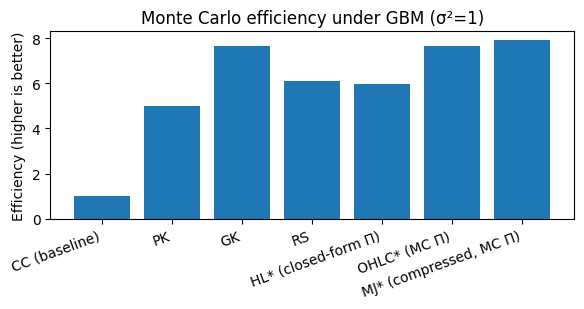


=== Bootstrap Efficiency (B = 1000, i.i.d. resample of per-day estimates) ===
             Estimator  Eff (point)  Eff (boot mean)  SE (boot)  CI 2.5%  CI 97.5%
         CC (baseline)       0.9890           0.9901     0.0248   0.9410    1.0398
                    PK       5.0005           5.0012     0.0918   4.8276    5.1785
                    GK       7.6698           7.6647     0.1157   7.4496    7.8852
                    RS       6.1132           6.1188     0.1014   5.9218    6.3146
   HL* (closed-form Π)       5.9768           5.9754     0.1027   5.7829    6.1738
          OHLC* (MC Π)       7.6275           7.6315     0.1184   7.4111    7.8707
MJ* (compressed, MC Π)       7.9021           7.9032     0.1125   7.6770    8.1181


In [47]:
"""
Monte Carlo Validation of Efficiency Results (driftless GBM, sigma^2 = 1)

Outputs a table with:
- per-day estimator variance  Var(est)
- Efficiency = 2 / Var(est)   (since Var(CC) = 2 under σ^2=1)

Estimators:
- CC       : close-to-close squared return
- PK       : Parkinson
- GK       : Garman–Klass (no drift)
- RS       : Rogers–Satchell (drift-robust)
- HL*      : Minimum-variance (HL family) from closed-form Π (module)
- OHLC*    : Minimum-variance (OHLC family) from Monte-Carlo Π
- MJ* (c)  : Minimum-variance (OHLC family) with Meilijson compression and MC Π

"""

# ---------------- Tunables (speed vs accuracy) ----------------
N_PATHS_WEIGHTS = 20_000   # MC size to compute OHLC* / MJ* weights (Π from MC)
N_STEPS_WEIGHTS = 700_000

N_PATHS_EVAL    = 20_000   # MC size to evaluate per-day variances (efficiencies)
N_STEPS_EVAL    = 700_000

SEED_WEIGHTS    = 123
SEED_EVAL       = 123
# ---------------------------------------------------------------


# ---------------- Helper: Meilijson compression ----------------
def compress_arrays(u, d, c):
    """
    Meilijson (2009) compression by sign of c:
      if c >= 0: keep (u, d, c)
      if c <  0: reflect (-d, -u, -c)
    Ensures u>=0, d<=0, c>=0 after compression.
    """
    u = np.asarray(u); d = np.asarray(d); c = np.asarray(c)
    mask = (c >= 0)
    u_out = np.where(mask, u, -d)
    d_out = np.where(mask, d, -u)
    c_out = np.where(mask, c, -c)
    return u_out, d_out, c_out

# ---------------- 1) Compute weights ----------------
# HL* (closed-form Π from the module)
hl_w = hl_optimal_weights()  # dict: {"u2","d2","u_d"}

# OHLC* (Monte-Carlo Π) using the module’s helper
ohlc_w = ohlc_nullspace_optimal_weights_monte_carlo(
    n_paths=N_PATHS_WEIGHTS, n_steps=N_STEPS_WEIGHTS, seed=SEED_WEIGHTS
)  # dict: ["u2","d2","c2","u_d","u_c","d_c"]

# MJ* (compressed OHLC) weights via MC Π on compressed features
sim_w = simulate_bm_day_extremes(
    n_paths=N_PATHS_WEIGHTS, n_steps=N_STEPS_WEIGHTS, seed=SEED_WEIGHTS+1
)
u_w, d_w, c_w = sim_w["u"], sim_w["d"], sim_w["c"]
u_cw, d_cw, c_cw = compress_arrays(u_w, d_w, c_w)
Xc = np.column_stack([u_cw**2, d_cw**2, c_cw**2, u_cw*d_cw, u_cw*c_cw, d_cw*c_cw])
Kc_hat = Xc.mean(axis=0, keepdims=True)
Pic_hat = empirical_covariance_matrix(Xc)
a_MJ_star, _ = optimal_weights_from_nullspace(Kc_hat, np.array([1.0]), Pic_hat)
mj_w = dict(zip(["u2","d2","c2","u_d","u_c","d_c"], a_MJ_star))

# ---------------- 2) Evaluate per-day variances (efficiencies) ----------------
# Simulate fresh paths for evaluation
sim = simulate_bm_day_extremes(
    n_paths=N_PATHS_EVAL, n_steps=N_STEPS_EVAL, seed=SEED_EVAL
)
u, d, c = sim["u"], sim["d"], sim["c"]

# Derived basic terms
hl = u - d           # ln(H/L)
c2 = c**2
u2 = u**2
d2 = d**2
ud = u * d
uc = u * c
dc = d * c

# Per-day estimators (vectorized)
# CC (squared close-to-open; here open equals previous close under driftless GBM)
CC = c2

# Parkinson
PK = (hl**2) / (4.0 * math.log(2.0))

# Garman–Klass (no drift)
GK = 0.5 * hl**2 - (2.0 * math.log(2.0) - 1.0) * c2

# Rogers–Satchell
RS = u * (u - c) + d * (d - c)

# HL* per-day using HL* weights
HL_star = (
    hl_w["u2"] * u2 +
    hl_w["d2"] * d2 +
    hl_w["u_d"] * (ud)
)

# OHLC* per-day using OHLC* weights
OHLC_star = (
    ohlc_w["u2"] * u2 +
    ohlc_w["d2"] * d2 +
    ohlc_w["c2"] * c2 +
    ohlc_w["u_d"] * (ud) +
    ohlc_w["u_c"] * (uc) +
    ohlc_w["d_c"] * (dc)
)

# MJ* (compressed OHLC*) per-day
u_ce, d_ce, c_ce = compress_arrays(u, d, c)
MJ_star = (
    mj_w["u2"] * (u_ce**2) +
    mj_w["d2"] * (d_ce**2) +
    mj_w["c2"] * (c_ce**2) +
    mj_w["u_d"] * (u_ce * d_ce) +
    mj_w["u_c"] * (u_ce * c_ce) +
    mj_w["d_c"] * (d_ce * c_ce)
)

# ---------------- 3) Compute sample variances and efficiencies ----------------
def sample_var(x):
    return float(np.var(x, ddof=1))

var_CC   = sample_var(CC)
var_PK   = sample_var(PK)
var_GK   = sample_var(GK)
var_RS   = sample_var(RS)
var_HL   = sample_var(HL_star)
var_OHLC = sample_var(OHLC_star)
var_MJ   = sample_var(MJ_star)

# Under σ^2 = 1, Var(CC) = Var(Z^2) with Z~N(0,1) = 2  (reference)
# Efficiency = 2 / Var(estimator)
eff = lambda v: 2.0 / v

eff_CC   = eff(var_CC)
eff_PK   = eff(var_PK)
eff_GK   = eff(var_GK)
eff_RS   = eff(var_RS)
eff_HL   = eff(var_HL)
eff_OHLC = eff(var_OHLC)
eff_MJ   = eff(var_MJ)

# ---------------- 4) Display results ----------------
import pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:0.6f}")

tbl = pd.DataFrame({
    "Estimator": [
        "CC (baseline)", "PK", "GK", "RS", "HL* (closed-form Π)",
        "OHLC* (MC Π)", "MJ* (compressed, MC Π)"
    ],
    "Var(per-day)": [
        var_CC, var_PK, var_GK, var_RS, var_HL, var_OHLC, var_MJ
    ],
    "Efficiency = 2 / Var": [
        eff_CC, eff_PK, eff_GK, eff_RS, eff_HL, eff_OHLC, eff_MJ
    ],
})

print("\n=== Monte Carlo Efficiency Validation (σ^2 = 1, μ = 0, no jumps) ===")
print(f"Paths (weights) : {N_PATHS_WEIGHTS}  with {N_STEPS_WEIGHTS} steps/day")
print(f"Paths (eval)    : {N_PATHS_EVAL}      with {N_STEPS_EVAL} steps/day\n")
print(tbl.to_string(index=False))

try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(6.0, 3.2))
    plt.bar(tbl["Estimator"], tbl["Efficiency = 2 / Var"])
    plt.ylabel("Efficiency (higher is better)")
    plt.xticks(rotation=20, ha="right")
    plt.title("Monte Carlo efficiency under GBM (σ²=1)")
    plt.tight_layout()
    plt.show()
except Exception:
    pass

# -----------------------------------------------------------
# Bootstrap SEs and 95% CIs for Efficiency = 2 / Var(estimator)
# Resample per-day estimates i.i.d. with replacement.
# -----------------------------------------------------------
# ---------- settings ----------
B_BOOT   = 1000     # number of bootstrap replications
SEEDBOOT = 2025     # bootstrap RNG seed
# -----------------------------

rng = np.random.default_rng(SEEDBOOT)

def sample_variance(x):
    """Sample variance with ddof=1 (per-day estimator variance)."""
    return float(np.var(x, ddof=1))

def efficiency_from_series(x):
    """Efficiency = 2 / Var with σ² = 1 baseline."""
    v = sample_variance(x)
    return 2.0 / v

# NEW: Numba-accelerated bootstrap
if NUMBA_AVAILABLE:
    @jit(nopython=True, parallel=True)
    def _bootstrap_variance_numba(x: np.ndarray, n_boot: int, seed: int):
        """5-10x faster bootstrap with Numba."""
        np.random.seed(seed)
        n = len(x)
        boot_vars = np.empty(n_boot)

        for b in prange(n_boot):  # Parallel!
            # Resample
            indices = np.random.randint(0, n, size=n)
            xb = x[indices]

            # Compute variance
            mean_xb = xb.mean()
            var_xb = 0.0
            for i in range(n):
                diff = xb[i] - mean_xb
                var_xb += diff * diff
            var_xb /= (n - 1)

            boot_vars[b] = var_xb

        return boot_vars


def bootstrap_efficiency(x, B=1000, rng=None, seed=None):
    """
    OPTIMIZED: Bootstrap with optional Numba acceleration.
    """
    x = np.asarray(x, float)
    n = x.shape[0]

    # Point estimate
    var_hat = float(np.var(x, ddof=1))
    eff_hat = 2.0 / var_hat

    # Use Numba if available
    if NUMBA_AVAILABLE and seed is not None:
        boot_vars = _bootstrap_variance_numba(x, B, seed)
        eff_boot = 2.0 / boot_vars
    else:
        # Fallback: original implementation
        if rng is None:
            rng = np.random.default_rng(seed)

        eff_boot = np.empty(B, dtype=float)
        for b in range(B):
            idx = rng.integers(0, n, size=n)
            xb = x[idx]
            var_b = float(np.var(xb, ddof=1))
            eff_boot[b] = 2.0 / var_b

    # Summarize
    se = float(np.std(eff_boot, ddof=1))
    lo95 = float(np.percentile(eff_boot, 2.5))
    hi95 = float(np.percentile(eff_boot, 97.5))

    return {
        "Eff_point": eff_hat,
        "Eff_boot_mean": float(np.mean(eff_boot)),
        "SE_boot": se,
        "CI95_lo": lo95,
        "CI95_hi": hi95,
    }

# THEN UPDATE the bootstrap calls (lines ~1150-1158) to pass seed:
results = {}
results["CC (baseline)"] = bootstrap_efficiency(CC, B_BOOT, seed=SEEDBOOT)
results["PK"] = bootstrap_efficiency(PK, B_BOOT, seed=SEEDBOOT+1)
results["GK"] = bootstrap_efficiency(GK, B_BOOT, seed=SEEDBOOT+2)
results["RS"] = bootstrap_efficiency(RS, B_BOOT, seed=SEEDBOOT+3)
results["HL* (closed-form Π)"] = bootstrap_efficiency(HL_star, B_BOOT, seed=SEEDBOOT+4)
results["OHLC* (MC Π)"] = bootstrap_efficiency(OHLC_star, B_BOOT, seed=SEEDBOOT+5)
results["MJ* (compressed, MC Π)"] = bootstrap_efficiency(MJ_star, B_BOOT, seed=SEEDBOOT+6)

# ---------- run bootstrap for each estimator ----------

# results["CC (baseline)"]              = bootstrap_efficiency(CC,         B_BOOT, rng)
# results["PK"]                         = bootstrap_efficiency(PK,         B_BOOT, rng)
# results["GK"]                         = bootstrap_efficiency(GK,         B_BOOT, rng)
# results["RS"]                         = bootstrap_efficiency(RS,         B_BOOT, rng)
# results["HL* (closed-form Π)"]        = bootstrap_efficiency(HL_star,    B_BOOT, rng)
# results["OHLC* (MC Π)"]               = bootstrap_efficiency(OHLC_star,  B_BOOT, rng)
# results["MJ* (compressed, MC Π)"]     = bootstrap_efficiency(MJ_star,    B_BOOT, rng)

# ---------- pretty table ----------
tbl_boot = pd.DataFrame([
    {"Estimator": k,
     "Eff (point)": v["Eff_point"],
     "Eff (boot mean)": v["Eff_boot_mean"],
     "SE (boot)": v["SE_boot"],
     "CI 2.5%": v["CI95_lo"],
     "CI 97.5%": v["CI95_hi"]}
    for k, v in results.items()
])

pd.set_option("display.float_format", lambda z: f"{z:0.4f}")
print("\n=== Bootstrap Efficiency (B = {}, i.i.d. resample of per-day estimates) ===".format(B_BOOT))
print(tbl_boot.to_string(index=False))